# Phase 6: Unsupervised Fraud Detection + Phase 7: Hybrid Risk Scoring

## Phase 6, Step 1: Setup & Load Everything

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              average_precision_score, confusion_matrix)

# Load processed splits
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load the best supervised model from Phase 5 (LightGBM)
best_supervised_model = joblib.load('../models/best_supervised_model.pkl')
print('Loaded best supervised model:', type(best_supervised_model).__name__)

fraud_rate = y_train.mean()
print('Fraud rate in training data: {:.4f}%'.format(fraud_rate*100))

Loaded best supervised model: LGBMClassifier
Fraud rate in training data: 0.1667%


## Phase 6, Step 2: Isolation Forest

In [2]:
# Isolation Forest is trained UNSUPERVISED (no y_train used for fitting) on the raw
# (non-resampled) training data, since it must learn what "normal" transactions look like.
# contamination = expected proportion of anomalies, set close to real fraud rate.
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)

# score_samples: higher = more normal. We flip sign so higher = more anomalous (like a fraud score)
iso_scores_val = -iso_forest.score_samples(X_val)
# Normalize to 0-1 range for easier interpretation and later combination in Phase 7
iso_scores_val_norm = (iso_scores_val - iso_scores_val.min()) / (iso_scores_val.max() - iso_scores_val.min())

iso_pred = iso_forest.predict(X_val)  # -1 = anomaly (fraud), 1 = normal
iso_pred_binary = np.where(iso_pred == -1, 1, 0)

unsupervised_results = {}
unsupervised_results['Isolation Forest'] = {
    'Precision': precision_score(y_val, iso_pred_binary),
    'Recall': recall_score(y_val, iso_pred_binary),
    'F1': f1_score(y_val, iso_pred_binary),
    'ROC-AUC': roc_auc_score(y_val, iso_scores_val_norm),
    'PR-AUC': average_precision_score(y_val, iso_scores_val_norm)
}

print('--- Isolation Forest ---')
for k, v in unsupervised_results['Isolation Forest'].items():
    print(f'{k}: {v:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, iso_pred_binary))

--- Isolation Forest ---
Precision: 0.2258
Recall: 0.1972
F1: 0.2105
ROC-AUC: 0.9281
PR-AUC: 0.1182

Confusion Matrix:
[[42440    48]
 [   57    14]]


## Phase 6, Step 3: One-Class SVM

In [3]:
# One-Class SVM is very slow on large datasets (O(n^2) or worse), so we train it on a
# random subsample of the training data. This is standard practice for this algorithm.
sample_size = 5000
X_train_sample = X_train.sample(n=sample_size, random_state=42)

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=fraud_rate)
ocsvm.fit(X_train_sample)

ocsvm_scores_val = -ocsvm.decision_function(X_val)  # higher = more anomalous
ocsvm_scores_val_norm = (ocsvm_scores_val - ocsvm_scores_val.min()) / (ocsvm_scores_val.max() - ocsvm_scores_val.min())

ocsvm_pred = ocsvm.predict(X_val)  # -1 = anomaly, 1 = normal
ocsvm_pred_binary = np.where(ocsvm_pred == -1, 1, 0)

unsupervised_results['One-Class SVM'] = {
    'Precision': precision_score(y_val, ocsvm_pred_binary),
    'Recall': recall_score(y_val, ocsvm_pred_binary),
    'F1': f1_score(y_val, ocsvm_pred_binary),
    'ROC-AUC': roc_auc_score(y_val, ocsvm_scores_val_norm),
    'PR-AUC': average_precision_score(y_val, ocsvm_scores_val_norm)
}

print('--- One-Class SVM (trained on 5,000-row sample) ---')
for k, v in unsupervised_results['One-Class SVM'].items():
    print(f'{k}: {v:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, ocsvm_pred_binary))

--- One-Class SVM (trained on 5,000-row sample) ---
Precision: 0.0279
Recall: 0.8310
F1: 0.0540
ROC-AUC: 0.9093
PR-AUC: 0.0991

Confusion Matrix:
[[40433  2055]
 [   12    59]]


## Phase 6, Step 4: Compare Unsupervised Approaches

=== Unsupervised Approach Comparison ===

                  Precision  Recall      F1  ROC-AUC  PR-AUC
Isolation Forest     0.2258  0.1972  0.2105   0.9281  0.1182
One-Class SVM        0.0279  0.8310  0.0540   0.9093  0.0991

Best unsupervised approach by PR-AUC: Isolation Forest


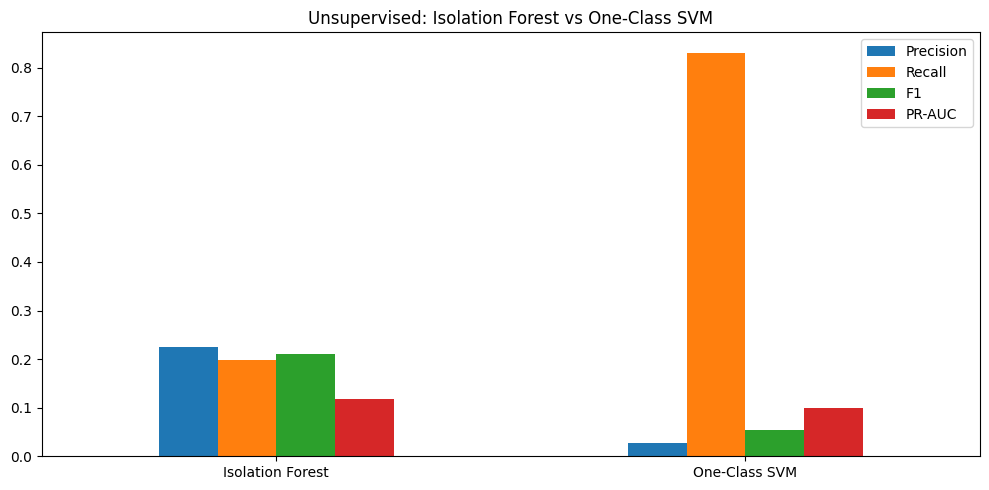


Saved to models/unsupervised_comparison.csv

Note: supervised models (Phase 5) will outperform these on their own — that is expected.
Unsupervised anomaly scores add value in Phase 7 by catching NEW/unusual fraud patterns
that the supervised model was never trained on.


In [4]:
unsup_comparison_df = pd.DataFrame(unsupervised_results).T.round(4)
unsup_comparison_df = unsup_comparison_df.sort_values('PR-AUC', ascending=False)
print('=== Unsupervised Approach Comparison ===\n')
print(unsup_comparison_df)

best_unsupervised_name = unsup_comparison_df.index[0]
print('\nBest unsupervised approach by PR-AUC:', best_unsupervised_name)

unsup_comparison_df.plot(kind='bar', y=['Precision','Recall','F1','PR-AUC'], figsize=(10,5))
plt.title('Unsupervised: Isolation Forest vs One-Class SVM')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

unsup_comparison_df.to_csv('../models/unsupervised_comparison.csv')
print('\nSaved to models/unsupervised_comparison.csv')
print('\nNote: supervised models (Phase 5) will outperform these on their own — that is expected.')
print('Unsupervised anomaly scores add value in Phase 7 by catching NEW/unusual fraud patterns')
print('that the supervised model was never trained on.')

---
# Phase 7: Hybrid Fraud Detection

Combine the supervised fraud probability (LightGBM) with the unsupervised anomaly score (Isolation Forest — the better performer from Phase 6) into a single Risk Score.

In [5]:
# Step 1: Get supervised fraud probability from the best model (LightGBM)
fraud_probability = best_supervised_model.predict_proba(X_val)[:, 1]

# Step 2: Get anomaly score from Isolation Forest (already computed above, 0-1 normalized)
anomaly_score = iso_scores_val_norm

# Step 3: Combine into a Hybrid Risk Score.
# Weighted average: supervised model gets more weight since it was trained on labeled fraud
# patterns and is much more accurate; unsupervised score adds robustness to unseen patterns.
SUPERVISED_WEIGHT = 0.7
ANOMALY_WEIGHT = 0.3

risk_score = (SUPERVISED_WEIGHT * fraud_probability) + (ANOMALY_WEIGHT * anomaly_score)
risk_score_100 = (risk_score * 100).round(2)  # scale to 0-100 for the Risk Scoring phase later

print('Sample hybrid risk scores (first 10 validation transactions):')
hybrid_preview = pd.DataFrame({
    'Fraud_Probability': fraud_probability[:10].round(4),
    'Anomaly_Score': anomaly_score[:10].round(4),
    'Risk_Score_0_100': risk_score_100[:10],
    'Actual_Class': y_val.values[:10]
})
print(hybrid_preview)

Sample hybrid risk scores (first 10 validation transactions):
   Fraud_Probability  Anomaly_Score  Risk_Score_0_100  Actual_Class
0             0.0000         0.0730              2.19             0
1             0.0000         0.0590              1.77             0
2             0.0002         0.0577              1.74             0
3             0.0000         0.0430              1.29             0
4             0.0000         0.1393              4.18             0
5             0.0000         0.1042              3.12             0
6             0.0000         0.1898              5.69             0
7             0.0000         0.0742              2.23             0
8             0.0000         0.1237              3.71             0
9             0.0000         0.0426              1.28             0


In [6]:
# Evaluate the hybrid score itself as a fraud predictor
hybrid_pred_binary = (risk_score >= 0.5).astype(int)

print('--- Hybrid Model (0.7 * Supervised + 0.3 * Anomaly) ---')
print('Precision:', round(precision_score(y_val, hybrid_pred_binary), 4))
print('Recall:   ', round(recall_score(y_val, hybrid_pred_binary), 4))
print('F1:       ', round(f1_score(y_val, hybrid_pred_binary), 4))
print('ROC-AUC:  ', round(roc_auc_score(y_val, risk_score), 4))
print('PR-AUC:   ', round(average_precision_score(y_val, risk_score), 4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, hybrid_pred_binary))
print('\nCompare to LightGBM alone (Phase 5): PR-AUC 0.8253')
print('If hybrid PR-AUC is close to or better than 0.8253, the anomaly score is adding value.')

--- Hybrid Model (0.7 * Supervised + 0.3 * Anomaly) ---
Precision: 0.9444
Recall:    0.7183
F1:        0.816
ROC-AUC:   0.9402
PR-AUC:    0.7545

Confusion Matrix:
[[42485     3]
 [   20    51]]

Compare to LightGBM alone (Phase 5): PR-AUC 0.8253
If hybrid PR-AUC is close to or better than 0.8253, the anomaly score is adding value.


In [7]:
# Save everything needed for Phase 8 onward: the fitted Isolation Forest,
# the hybrid weights, and a reusable scoring function.
joblib.dump(iso_forest, '../models/isolation_forest.pkl')

hybrid_config = {
    'supervised_weight': SUPERVISED_WEIGHT,
    'anomaly_weight': ANOMALY_WEIGHT,
    'iso_score_min': float(iso_scores_val.min()),
    'iso_score_max': float(iso_scores_val.max())
}
joblib.dump(hybrid_config, '../models/hybrid_config.pkl')

print('Saved models/isolation_forest.pkl')
print('Saved models/hybrid_config.pkl (weights + normalization params for reuse in FastAPI later)')
print('\nPhase 6 & 7 complete. Ready for Phase 8: Model Evaluation.')

Saved models/isolation_forest.pkl
Saved models/hybrid_config.pkl (weights + normalization params for reuse in FastAPI later)

Phase 6 & 7 complete. Ready for Phase 8: Model Evaluation.
